FileNotFoundError: 1_sine_zero_flux/topography.00060 not found.

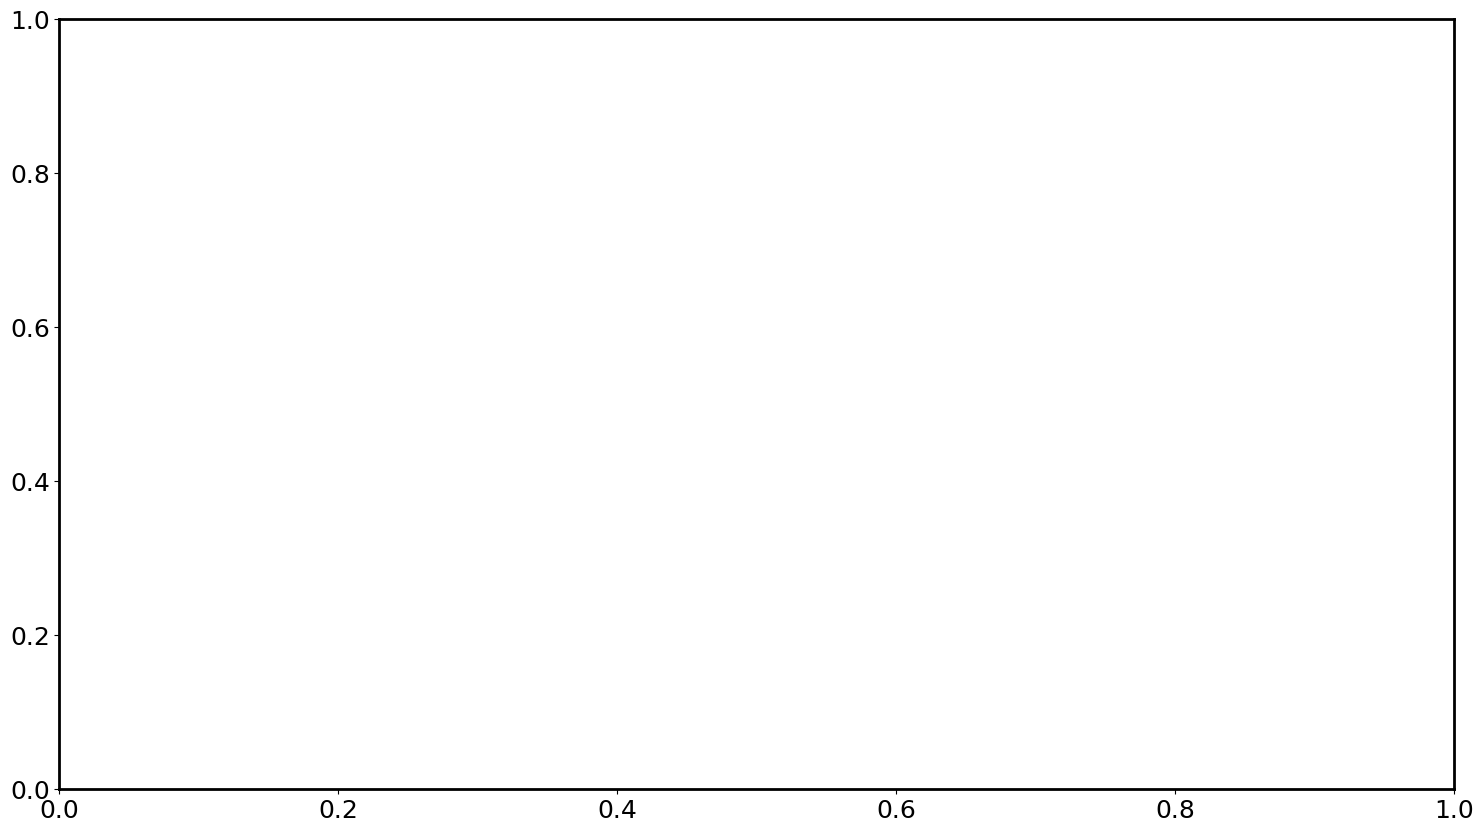

In [1]:
#!/usr/bin/env python3

# =============================================================================
#  Surface Topography Benchmark Plotter (Python Version)
#
#  This script reproduces the functionality of the original Gnuplot scripts:
#
#   1. Surface topography comparison
#   2. Percentage error plot
#
#  Only modify:
#
#      RUN_FOLDER
#      X_RANGE
#      Y_RANGE_TOPO
#      Y_RANGE_ERROR
#
# =============================================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# USER SETTINGS
# =============================================================================

RUN_FOLDER = (
    "1_sine_zero_flux"
    
)

X_RANGE = [0, 3]

Y_RANGE_TOPO = [0, 0.1]

Y_RANGE_ERROR = [0, 0.5]

# =============================================================================
# PATHS
# =============================================================================

OUTPUT_DIR = Path(RUN_FOLDER)

RESULT_DIR = OUTPUT_DIR / "result_benchmark_ASPECT"

RESULT_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# FILES
# =============================================================================

TIMES = [
    ("00060", "60",  "#1f77b4"),
    ("00120", "120", "#d62728"),
    ("00180", "180", "#2ca02c"),
]

# =============================================================================
# FIGURE SETTINGS
# =============================================================================

plt.rcParams.update({
    "font.size": 18,
    "axes.linewidth": 2,
})

# =============================================================================
# CREATE TOPOGRAPHY PLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(18, 10))

mad_values = []

for step, t, color in TIMES:

    file_path = OUTPUT_DIR / f"topography.{step}"

    data = np.loadtxt(file_path)

    x = data[:, 0]

    aspect = data[:, 2]

    analytical = data[:, 3]

    # -------------------------------------------------------------------------
    # MAD
    # -------------------------------------------------------------------------

    mad = np.mean(np.abs(aspect - analytical))

    mad_values.append((t, mad, color))

    # -------------------------------------------------------------------------
    # Plot ASPECT
    # -------------------------------------------------------------------------

    ax.plot(
        x,
        aspect,
        marker='o',
        linewidth=3,
        markersize=6,
        color=color,
        label=f"ASPECT t={t}"
    )

    # -------------------------------------------------------------------------
    # Plot analytical
    # -------------------------------------------------------------------------

    ax.plot(
        x,
        analytical,
        linestyle='--',
        linewidth=4,
        color=color,
        label=f"Analytical t={t}"
    )

# =============================================================================
# TOPOGRAPHY PLOT STYLE
# =============================================================================

ax.set_xlim(X_RANGE)

ax.set_ylim(Y_RANGE_TOPO)

ax.set_xlabel("X [-]", fontsize=22)

ax.set_ylabel("Topography [m]", fontsize=22)

ax.set_title(
    f"Surface Topography Benchmark ASPECT +\n{RUN_FOLDER}",
    fontsize=26
)

ax.grid(True, alpha=0.3)

ax.legend(
    loc="upper right",
    framealpha=1,
    fontsize=16
)

# =============================================================================
# MAD LABELS
# =============================================================================

ypos = 0.92

for t, mad, color in mad_values:

    ax.text(
        0.02,
        ypos,
        f"MAD t={t} = {mad:.3e} m",
        transform=ax.transAxes,
        color=color,
        fontsize=16
    )

    ypos -= 0.05

# =============================================================================
# SAVE TOPOGRAPHY FIGURE
# =============================================================================

topo_png = (
    RESULT_DIR /
    f"surface_topo_benchmark_ASPECT_{RUN_FOLDER}.png"
)

fig.savefig(
    topo_png,
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

# =============================================================================
# CREATE ERROR PLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(18, 10))

for step, t, color in TIMES:

    file_path = OUTPUT_DIR / f"topography.{step}"

    data = np.loadtxt(file_path)

    x = data[:, 0]

    aspect = data[:, 2]

    analytical = data[:, 3]

    # -------------------------------------------------------------------------
    # Percentage error
    # -------------------------------------------------------------------------

    error = np.abs(
        (analytical - aspect) / analytical
    ) * 100.0

    ax.plot(
        x,
        error,
        marker='o',
        linewidth=3,
        markersize=6,
        color=color,
        label=f"t={t}"
    )

# =============================================================================
# ERROR PLOT STYLE
# =============================================================================

ax.set_xlim(X_RANGE)

ax.set_ylim(Y_RANGE_ERROR)

ax.set_xlabel("X [-]", fontsize=22)

ax.set_ylabel("Error topography [%]", fontsize=22)

ax.set_title(
    f"Surface Topography Error Benchmark ASPECT +\n{RUN_FOLDER}",
    fontsize=26
)

ax.grid(True, alpha=0.3)

ax.legend(
    loc="upper center",
    framealpha=1,
    fontsize=16
)

# =============================================================================
# SAVE ERROR FIGURE
# =============================================================================

error_png = (
    RESULT_DIR /
    f"surface_topo_error_benchmark_ASPECT_{RUN_FOLDER}.png"
)

fig.savefig(
    error_png,
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

# =============================================================================
# FINAL MESSAGE
# =============================================================================

print()
print("Generated figures:")
print(f"  {topo_png}")
print(f"  {error_png}")
print()